In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy import stats
import boto3
import os
from tqdm import tqdm
import s3fs
import joblib
import warnings
warnings.filterwarnings('ignore')

try:
    import seaborn as sns
except:
    ! pip install seaborn
    import seaborn as sns

try:
    import optuna
    from optuna.samplers import TPESampler
except:
    ! pip install optuna
    import optuna
    from optuna.samplers import TPESampler

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

## Helper Classes

In [2]:
class SarimaModel:
    """SARIMA model development and evaluation."""
    
    def __init__(self, str_bucket, str_dirname_output):
        self.str_bucket = str_bucket
        self.str_dirname_output = str_dirname_output
        self.fs = s3fs.S3FileSystem()
        self.s3_client = boto3.client('s3')
        self.df_train = None
        self.df_test = None
        self.model = None
        self.model_results = None
        self.forecast_result = None
        self.tuple_best_order = None
        self.tuple_best_seasonal_order = None
        self.study = None
    
    def import_data(self):
        """Load train/test splits from S3."""
        str_train_uri = f's3://{self.str_bucket}/02_preprocessing/train_data.csv'
        str_test_uri = f's3://{self.str_bucket}/02_preprocessing/test_data.csv'
        
        self.df_train = pd.read_csv(str_train_uri)
        self.df_test = pd.read_csv(str_test_uri)
        
        self.df_train['date'] = pd.to_datetime(self.df_train['date'])
        self.df_test['date'] = pd.to_datetime(self.df_test['date'])
        
        print(f'Loaded train: {len(self.df_train)} samples')
        print(f'Loaded test: {len(self.df_test)} samples')
        
        return self.df_train, self.df_test
    
    def _objective(self, trial):
        """Optuna objective function to minimize AIC."""
        # Suggest parameters
        int_p = trial.suggest_int('p', 0, 2)
        int_d = trial.suggest_int('d', 0, 1)
        int_q = trial.suggest_int('q', 0, 2)
        int_P = trial.suggest_int('P', 0, 1)
        int_D = trial.suggest_int('D', 0, 1)
        int_Q = trial.suggest_int('Q', 0, 1)
        int_s = 12  # Fixed seasonal period
        
        try:
            model = SARIMAX(
                self.df_train['attrition_rate'],
                order=(int_p, int_d, int_q),
                seasonal_order=(int_P, int_D, int_Q, int_s),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            result = model.fit(disp=False)
            return result.aic
        except Exception as e:
            # If fitting fails, return large penalty
            return 1e10
    
    def optuna_search_order(self, int_n_trials=20):
        """Use Optuna to search parameter space."""
        print('Performing Optuna hyperparameter search...')
        
        # Create study with TPESampler
        sampler = TPESampler(seed=42)
        self.study = optuna.create_study(
            sampler=sampler,
            direction='minimize'
        )
        
        # Optimize
        self.study.optimize(self._objective, n_trials=int_n_trials, show_progress_bar=True)
        
        # Get best trial
        best_trial = self.study.best_trial
        int_p = best_trial.params['p']
        int_d = best_trial.params['d']
        int_q = best_trial.params['q']
        int_P = best_trial.params['P']
        int_D = best_trial.params['D']
        int_Q = best_trial.params['Q']
        int_s = 12
        
        self.tuple_best_order = (int_p, int_d, int_q)
        self.tuple_best_seasonal_order = (int_P, int_D, int_Q, int_s)
        
        print(f'\nOptuna Search Complete!')
        print(f'Best order: {self.tuple_best_order}')
        print(f'Best seasonal order: {self.tuple_best_seasonal_order}')
        print(f'Best AIC: {best_trial.value:.4f}')
        
        # Display top trials
        df_trials = self.study.trials_dataframe()
        df_trials_sorted = df_trials.sort_values('value').head(5)
        print(f'\nTop 5 trials:')
        print(df_trials_sorted[['number', 'value', 'params_p', 'params_d', 'params_q', 'params_P', 'params_D', 'params_Q']].to_string(index=False))
        
        return df_trials
    
    def fit_model(self):
        """Fit SARIMA with best parameters."""
        print(f'\nFitting SARIMA{self.tuple_best_order}x{self.tuple_best_seasonal_order}...')
        
        self.model = SARIMAX(self.df_train['attrition_rate'],
                            order=self.tuple_best_order,
                            seasonal_order=self.tuple_best_seasonal_order,
                            enforce_stationarity=False,
                            enforce_invertibility=False)
        
        self.model_results = self.model.fit(disp=False)
        
        print(f'\nModel Summary:')
        print(self.model_results.summary())
        
        return self.model_results
    
    def diagnose(self):
        """Residual diagnostics."""
        residuals = self.model_results.resid
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        # Residuals over time
        axes[0, 0].plot(residuals, linewidth=1)
        axes[0, 0].set_title('Residuals Over Time', fontsize=12, fontweight='bold')
        axes[0, 0].set_ylabel('Residual')
        axes[0, 0].grid(True, alpha=0.3)
        axes[0, 0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
        
        # Histogram with KDE
        axes[0, 1].hist(residuals, bins=20, density=True, alpha=0.6, edgecolor='black')
        residuals.plot(kind='kde', ax=axes[0, 1], secondary_y=False, linewidth=2, color='red')
        axes[0, 1].set_title('Distribution of Residuals', fontsize=12, fontweight='bold')
        axes[0, 1].set_xlabel('Residual')
        axes[0, 1].grid(True, alpha=0.3)
        
        # Q-Q plot
        stats.probplot(residuals, dist='norm', plot=axes[1, 0])
        axes[1, 0].set_title('Q-Q Plot', fontsize=12, fontweight='bold')
        axes[1, 0].grid(True, alpha=0.3)
        
        # ACF of residuals
        plot_acf(residuals, lags=40, ax=axes[1, 1])
        axes[1, 1].set_title('Autocorrelation of Residuals', fontsize=12, fontweight='bold')
        
        plt.tight_layout()
        str_path = f'{self.str_dirname_output}/11_sarima_diagnostics.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'\nSaved diagnostics to {str_path}')
        plt.show()
    
    def forecast(self, int_steps=12):
        """Generate forecast with confidence intervals."""
        self.forecast_result = self.model_results.get_forecast(steps=int_steps)
        df_forecast = self.forecast_result.conf_int(alpha=0.05)
        df_forecast['forecast'] = self.forecast_result.predicted_mean
        df_forecast.columns = ['ci_lower', 'ci_upper', 'forecast']
        
        print(f'\nGenerated {int_steps}-step forecast')
        print(df_forecast.head(10))
        
        return df_forecast
    
    def plot_forecast(self, df_forecast):
        """Plot actual vs forecast with CI bands."""
        fig, ax = plt.subplots(figsize=(14, 7))
        
        # Historical data
        ax.plot(self.df_train.index, self.df_train['attrition_rate'], linewidth=2, 
               label='Training Data', marker='o', markersize=4)
        ax.plot(self.df_test.index + len(self.df_train), self.df_test['attrition_rate'], 
               linewidth=2, label='Test Data', marker='s', markersize=4, color='#ff7f0e')
        
        # Forecast
        int_forecast_idx = np.arange(len(self.df_train), len(self.df_train) + len(df_forecast))
        ax.plot(int_forecast_idx, df_forecast['forecast'], linewidth=2.5, 
               label='SARIMA Forecast', marker='^', markersize=5, color='#d62728')
        
        # Confidence intervals
        ax.fill_between(int_forecast_idx, df_forecast['ci_lower'], df_forecast['ci_upper'],
                        alpha=0.3, color='#d62728', label='95% Confidence Interval')
        
        ax.set_xlabel('Time Index', fontsize=11)
        ax.set_ylabel('Attrition Rate', fontsize=11)
        ax.set_title('SARIMA Forecast vs Actual', fontsize=13, fontweight='bold')
        ax.legend(loc='best', fontsize=10)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        
        str_path = f'{self.str_dirname_output}/12_sarima_forecast.png'
        plt.savefig(str_path, bbox_inches='tight', dpi=150)
        print(f'Saved forecast plot to {str_path}')
        plt.show()
    
    def evaluate(self, df_forecast):
        """Calculate RMSE, MAE, MAPE on test set."""
        arr_actual = self.df_test['attrition_rate'].values
        arr_pred = df_forecast['forecast'].values[:len(arr_actual)]
        
        flt_rmse = np.sqrt(np.mean((arr_actual - arr_pred) ** 2))
        flt_mae = np.mean(np.abs(arr_actual - arr_pred))
        flt_mape = np.mean(np.abs((arr_actual - arr_pred) / arr_actual)) * 100
        
        dict_metrics = {
            'RMSE': flt_rmse,
            'MAE': flt_mae,
            'MAPE': flt_mape
        }
        
        print(f'\nTest Set Evaluation:')
        print(f'  RMSE: {flt_rmse:.6f}')
        print(f'  MAE: {flt_mae:.6f}')
        print(f'  MAPE: {flt_mape:.2f}%')
        
        return dict_metrics
    
    def save_model(self):
        """Serialize model to disk and S3."""
        str_model_path = f'{self.str_dirname_output}/sarima_model.pkl'
        joblib.dump(self.model_results, str_model_path)
        
        try:
            self.s3_client.upload_file(
                str_model_path,
                self.str_bucket,
                '03_sarima/sarima_model.pkl'
            )
            print(f'Saved model to {str_model_path} and S3')
        except Exception as e:
            print(f'Error uploading to S3: {e}')

## Constants

In [3]:
str_bucket = 'time-series-forecasting-demo'
str_task = 'employee_attrition_forecasting'
str_dirname_output = './output'

## Output Directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except FileExistsError:
    pass

print(f'Output directory: {str_dirname_output}')

Output directory: ./output


## Load Data

In [5]:
sarima = SarimaModel(str_bucket, str_dirname_output)
df_train, df_test = sarima.import_data()

Loaded train: 60 samples
Loaded test: 12 samples


In [6]:
# show
df_train

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2020-01-01,4544,705,686,0.151490,39.574227,7.103333
1,2020-01-31,4536,737,709,0.152697,40.776099,7.144393
2,2020-03-01,4570,546,554,0.117528,47.304553,7.200532
3,2020-03-31,4442,550,529,0.115409,41.572898,7.180251
4,2020-04-30,4451,512,494,0.106330,44.398178,6.717739
5,2020-05-30,4499,472,449,0.101233,42.774684,6.534091
6,2020-06-29,4505,381,357,0.076328,44.629461,7.709531
7,2020-07-29,4474,321,335,0.076421,38.959565,7.260049
8,2020-08-28,4465,466,415,0.089941,42.666650,6.891383
9,2020-09-27,4345,644,596,0.136549,46.852306,6.391925


In [7]:
df_test

,date,headcount,new_hires,departures,attrition_rate,avg_tenure_months,avg_satisfaction_score
0,2024-12-05,4496,492,446,0.094206,40.761716,7.014290
1,2025-01-04,4566,719,719,0.153480,38.886842,7.248555
2,2025-02-03,4549,657,640,0.135840,42.846596,7.841359
3,2025-03-05,4467,586,546,0.120267,37.931673,7.101528
4,2025-04-04,4623,485,475,0.100799,40.504860,6.622151
5,2025-05-04,4576,478,451,0.100968,44.721990,6.941815
6,2025-06-03,4569,354,343,0.074768,44.019060,7.136780
7,2025-07-03,4625,344,334,0.072719,42.300419,7.027890
8,2025-08-02,4585,444,440,0.092368,38.182424,7.468765
9,2025-09-01,4494,614,601,0.130019,42.470115,6.800370


## Optuna Hyperparameter Search


In [8]:
df_optuna_results = sarima.optuna_search_order(int_n_trials=20)

[I 2026-03-21 21:37:47,560] A new study created in memory with name: no-name-6811c30c-3062-4cd3-989a-8f820964863e


Performing Optuna hyperparameter search...


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-03-21 21:37:47,774] Trial 0 finished with value: -171.80288917041898 and parameters: {'p': 1, 'd': 1, 'q': 2, 'P': 1, 'D': 0, 'Q': 0}. Best is trial 0 with value: -171.80288917041898.
[I 2026-03-21 21:37:47,964] Trial 1 finished with value: -168.75398834963076 and parameters: {'p': 0, 'd': 1, 'q': 1, 'P': 1, 'D': 0, 'Q': 1}. Best is trial 0 with value: -171.80288917041898.
[I 2026-03-21 21:37:48,085] Trial 2 finished with value: -162.70768960783946 and parameters: {'p': 2, 'd': 0, 'q': 0, 'P': 0, 'D': 0, 'Q': 1}. Best is trial 0 with value: -171.80288917041898.
[I 2026-03-21 21:37:48,169] Trial 3 finished with value: -199.52745617431555 and parameters: {'p': 1, 'd': 0, 'q': 1, 'P': 0, 'D': 0, 'Q': 0}. Best is trial 3 with value: -199.52745617431555.
[I 2026-03-21 21:37:48,319] Trial 4 finished with value: -119.94185600322756 and parameters: {'p': 1, 'd': 1, 'q': 0, 'P': 1, 'D': 1, 'Q': 0}. Best is trial 3 with value: -199.52745617431555.
[I 2026-03-21 21:37:48,571] Trial 5 fini

## Fit Best Model

In [9]:
result = sarima.fit_model()


Fitting SARIMA(1, 0, 1)x(0, 0, 0, 12)...

Model Summary:
                               SARIMAX Results                                
Dep. Variable:         attrition_rate   No. Observations:                   60
Model:               SARIMAX(1, 0, 1)   Log Likelihood                 102.764
Date:                Sat, 21 Mar 2026   AIC                           -199.527
Time:                        21:37:50   BIC                           -193.346
Sample:                             0   HQIC                          -197.120
                                 - 60                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9972      0.005    202.342      0.000       0.988       1.007
ma.L1         -1.0000    225.484     -0.004      0.996    -442.941     44

## Diagnostic Checks


Saved diagnostics to ./output/11_sarima_diagnostics.png


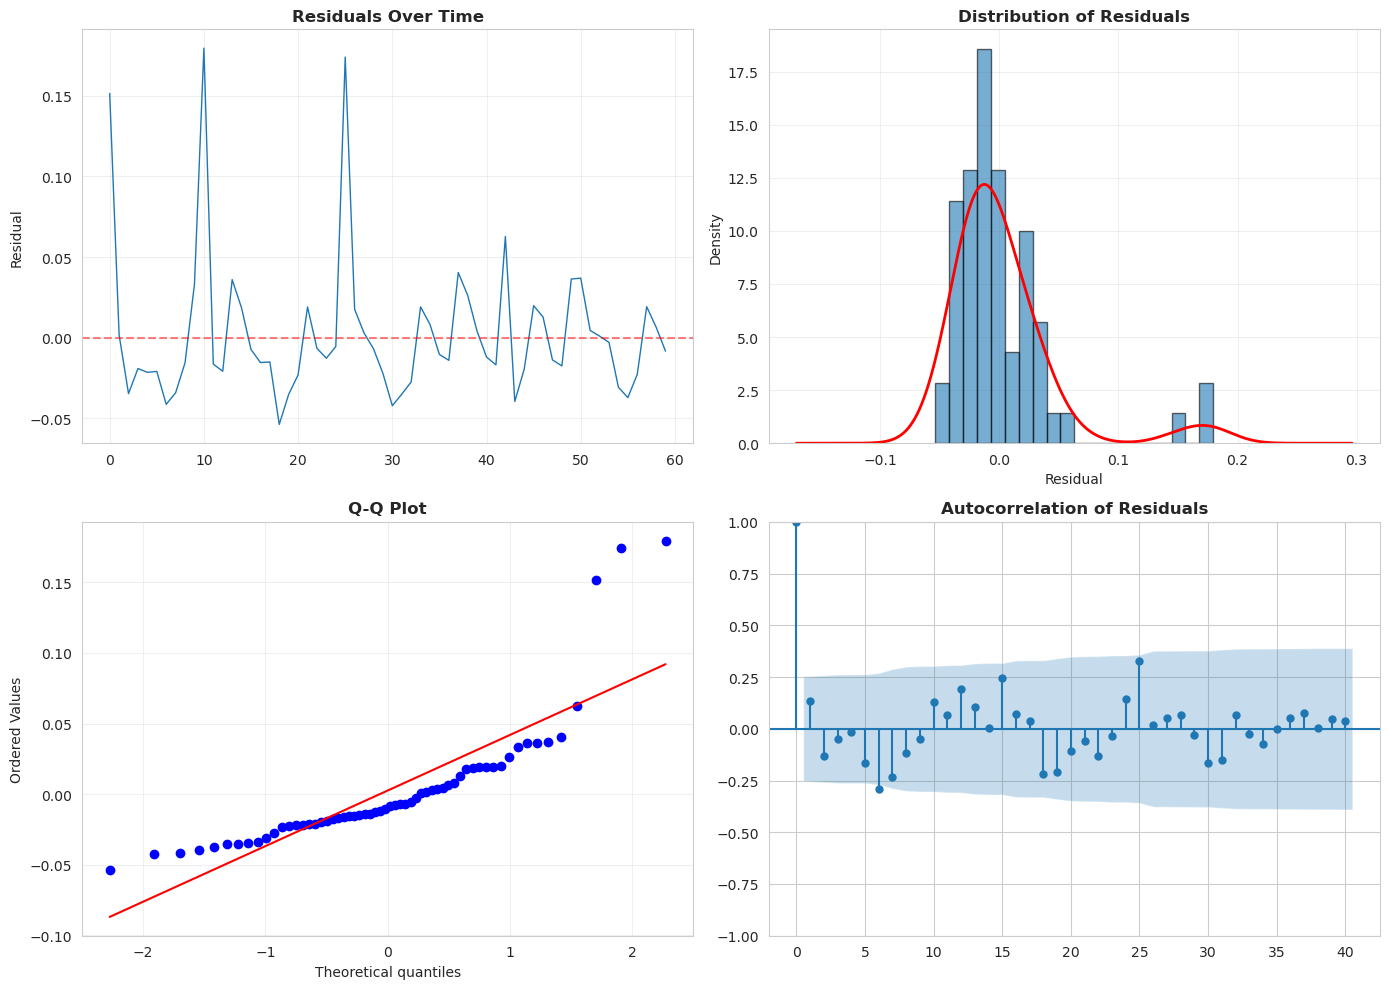

In [10]:
sarima.diagnose()

## Generate Forecast

In [11]:
df_forecast = sarima.forecast(int_steps=12)


Generated 12-step forecast
    ci_lower  ci_upper  forecast
60  0.027206  0.184206  0.105706
61  0.026915  0.183908  0.105411
62  0.026624  0.183611  0.105118
63  0.026335  0.183315  0.104825
64  0.026046  0.183020  0.104533
65  0.025758  0.182725  0.104241
66  0.025470  0.182431  0.103951
67  0.025184  0.182138  0.103661
68  0.024898  0.181846  0.103372
69  0.024614  0.181555  0.103084


## Plot Forecast

Saved forecast plot to ./output/12_sarima_forecast.png


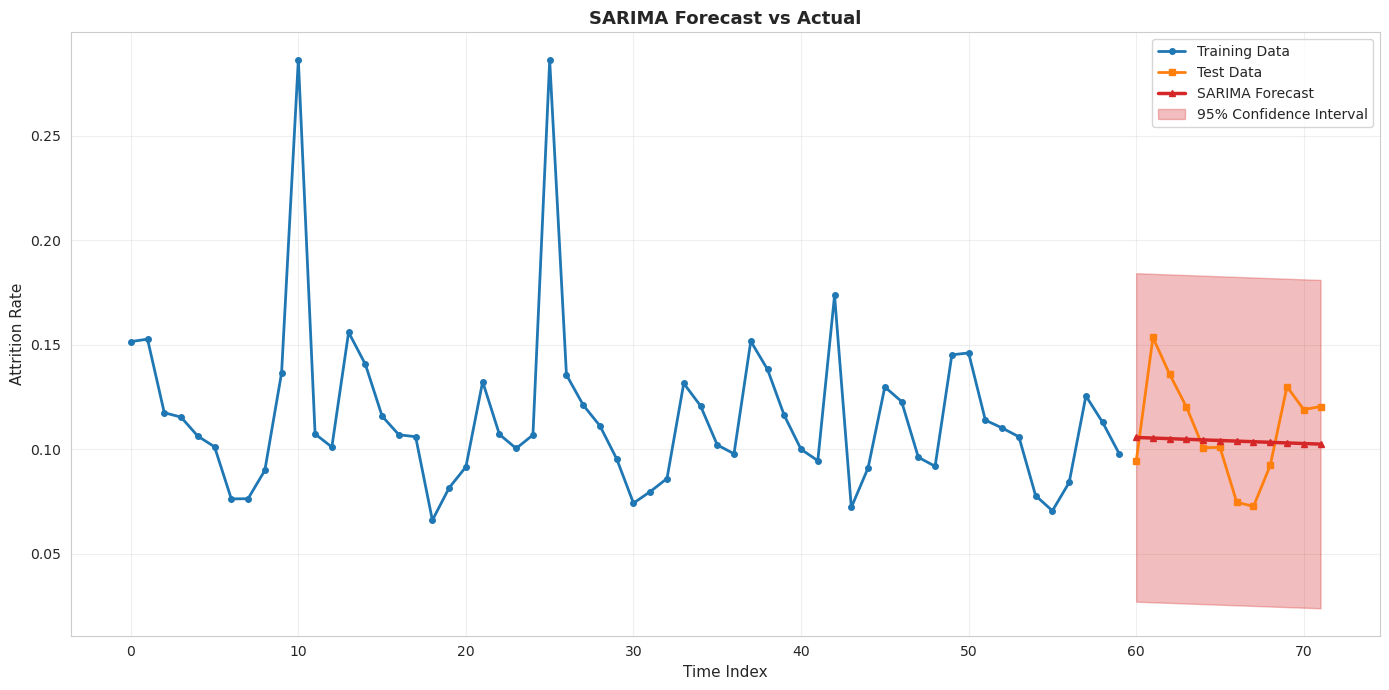

In [12]:
sarima.plot_forecast(df_forecast)

## Evaluate Model

In [13]:
dict_metrics = sarima.evaluate(df_forecast)


Test Set Evaluation:
  RMSE: 0.023962
  MAE: 0.020413
  MAPE: 19.06%


## Save Model

In [14]:
sarima.save_model()

Saved model to ./output/sarima_model.pkl and S3


## Model Summary

In [15]:
print(f'\n=== SARIMA MODEL SUMMARY ===')
print(f'Order: {sarima.tuple_best_order}')
print(f'Seasonal Order: {sarima.tuple_best_seasonal_order}')
print(f'Test RMSE: {dict_metrics["RMSE"]:.6f}')
print(f'Test MAE: {dict_metrics["MAE"]:.6f}')
print(f'Test MAPE: {dict_metrics["MAPE"]:.2f}%')
print(f'\nModel ready for production deployment!')


=== SARIMA MODEL SUMMARY ===
Order: (1, 0, 1)
Seasonal Order: (0, 0, 0, 12)
Test RMSE: 0.023962
Test MAE: 0.020413
Test MAPE: 19.06%

Model ready for production deployment!
